### Supply Chain

**Dataset:** DataCo Smart Supply Chain — 180,519 orders, 53 features

### 1. Imports

In [84]:
import time
import os
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-darkgrid')
import unicodedata
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier , callback
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder


### 2. Load Data

In [3]:
df_raw = pd.read_csv('datasets/DataCoSupplyChainDataset.csv', encoding='latin-1')
df = df_raw.copy()

In [4]:
df.shape

(180519, 53)

### 3. Initial Exploration

In [6]:
df.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Benefit per order', 'Sales per customer', 'Delivery Status',
       'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City',
       'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id',
       'Customer Lname', 'Customer Password', 'Customer Segment',
       'Customer State', 'Customer Street', 'Customer Zipcode',
       'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market',
       'Order City', 'Order Country', 'Order Customer Id',
       'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id',
       'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id',
       'Order Item Product Price', 'Order Item Profit Ratio',
       'Order Item Quantity', 'Sales', 'Order Item Total',
       'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status',
       'Order Zipcode', 'Product Card Id', 'Product Category Id',
       'Product De

### Business Domains and Pain Points

| Domain        | Common Business Pain Points                                      |
|---------------|------------------------------------------------------------------|
| Supply Chain  | Late deliveries, demand forecasting, fraud, inventory loss       |
| Finance       | Fraud detection, profit prediction                               |
| Logistics     | Shipping delays, route optimization                              |

### Question

**What would a supply chain company lose money on?**

A supply chain company can lose money due to:
- Late deliveries  
- Fraud  
- Unpredicted demand  

### Target Variable Identification

In [7]:
# See all columns and their data types
df.dtypes.reset_index().rename(columns={'index':'Column', 0:'Type'})

# Check columns with binary values (0/1) for finding out target
binary_cols = [col for col in df.columns if df[col].nunique() == 2]
print("Binary columns (0/1) :", binary_cols)

# Check columns with few unique values for classification 
low_unique = [col for col in df.columns if df[col].nunique() <= 6]
print("Low unique values columns (Classification targets):", low_unique)

# Check fully numeric columns for regression 
numeric_cols = df.select_dtypes(include='number').columns.tolist()
print("Numeric columns (regression targets):", numeric_cols)

Binary columns (0/1) : ['Late_delivery_risk', 'Customer Country']
Low unique values columns (Classification targets): ['Type', 'Days for shipment (scheduled)', 'Delivery Status', 'Late_delivery_risk', 'Customer Country', 'Customer Email', 'Customer Password', 'Customer Segment', 'Market', 'Order Item Quantity', 'Product Description', 'Product Status', 'Shipping Mode']
Numeric columns (regression targets): ['Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Late_delivery_risk', 'Category Id', 'Customer Id', 'Customer Zipcode', 'Department Id', 'Latitude', 'Longitude', 'Order Customer Id', 'Order Id', 'Order Item Cardprod Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Order Zipcode', 'Product Card Id', 'Product Category Id', 'Product Description', 'Product Price', 'Product Stat

In [8]:
def data_info(data):
    print('- Number of columns are : ',data.shape[1])
    print('- Number of rows are : ',data.shape[0])
    print('- Total number of data-points :',data.size)
    numerical_features = [f for f in data.columns if data[f].dtypes!='O']
    print('- Count of Numerical Features :',len(numerical_features))
    cat_features = [c for c in data.columns if data[c].dtypes=='O']
    print('- Count of Categorical Features :',len(cat_features))
    
data_info(df)    

- Number of columns are :  53
- Number of rows are :  180519
- Total number of data-points : 9567507
- Count of Numerical Features : 29
- Count of Categorical Features : 24


In [ ]:
df.isnull().sum(axis = 0)

Type                                  0
Days for shipping (real)              0
Days for shipment (scheduled)         0
Benefit per order                     0
Sales per customer                    0
Delivery Status                       0
Late_delivery_risk                    0
Category Id                           0
Category Name                         0
Customer City                         0
Customer Country                      0
Customer Email                        0
Customer Fname                        0
Customer Id                           0
Customer Lname                        8
Customer Password                     0
Customer Segment                      0
Customer State                        0
Customer Street                       0
Customer Zipcode                      3
Department Id                         0
Department Name                       0
Latitude                              0
Longitude                             0
Market                                0


In [10]:
df.isnull().sum(axis = 1)


0         2
1         2
2         2
3         2
4         2
         ..
180514    2
180515    2
180516    2
180517    2
180518    2
Length: 180519, dtype: int64

In [ ]:
def missing_values_table(df):
    mis_val = df.isnull().sum()
    mis_val_percent = mis_val * 100 / len(df)
    mis_val_table = pd.concat([mis_val, mis_val_percent], axis=1)
    mis_val_table_rename_columns = mis_val_table.copy()
    mis_val_table_rename_columns.columns = ['Missing Values', '% of Total Values']
    mis_val_table_rename_columns = mis_val_table_rename_columns[
        mis_val_table_rename_columns['Missing Values'] != 0
    ]
    mis_val_table_rename_columns = mis_val_table_rename_columns.sort_values(
        '% of Total Values', ascending=False
    ).round(1)
    print("Your selected dataframe has " + str(df.shape[1]) + " columns.\n"
          "There are " + str(mis_val_table_rename_columns.shape[0]) +
          " columns that have missing values.")
    return mis_val_table_rename_columns

missing_values_table(df)


Your selected dataframe has 53 columns.
There are 4 columns that have missing values.


,Missing Values,% of Total Values
Product Description,180519,100.0
Order Zipcode,155679,86.2
Customer Lname,8,0.0
Customer Zipcode,3,0.0


### 4. Correlation & Duplicate Analysis

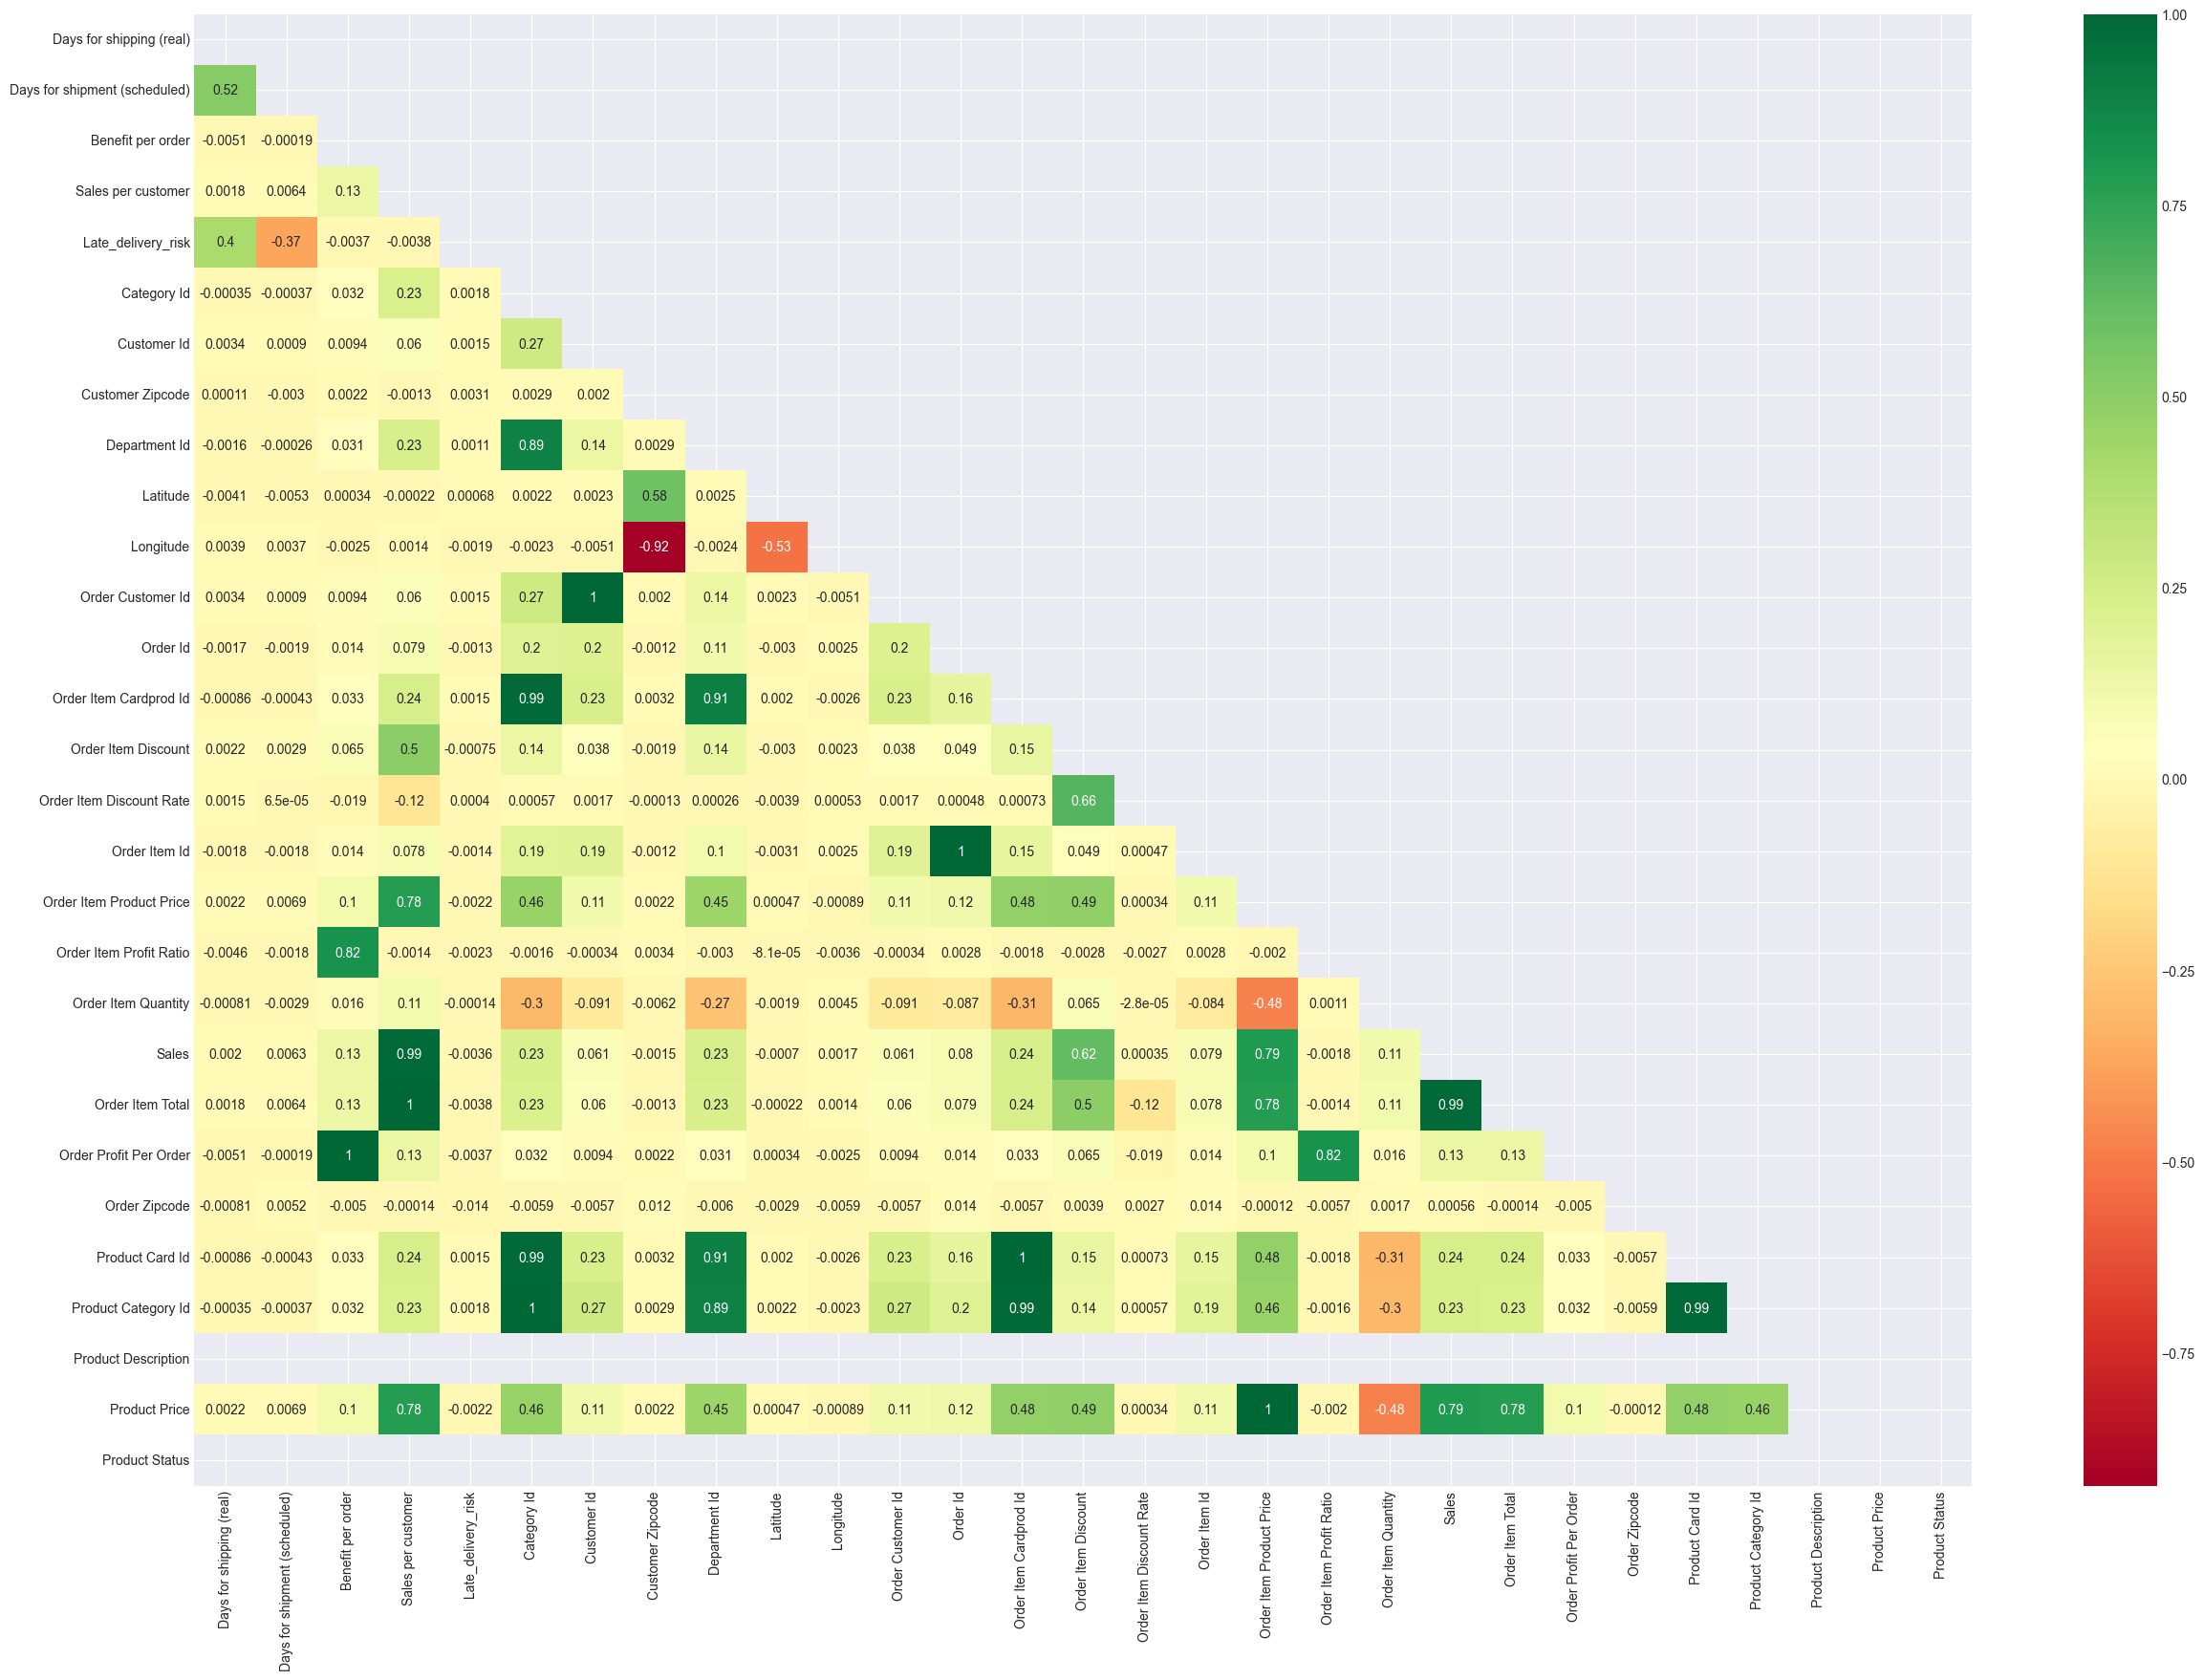

In [12]:
corrmap = df.corr(numeric_only=True)
top = corrmap.index

# mask for the upper triangle
mask = np.triu(np.ones_like(corrmap, dtype=bool))
plt.figure(figsize=(30,20))
g = sns.heatmap(df[top].corr(numeric_only=True), annot=True, cmap="RdYlGn", mask=mask)
plt.show()

### Insights from the Heatmap

#### 1. Duplicate or Redundant Columns
Some columns contain the same or very similar values but have different names due to metadata differences. These columns should be reviewed before model building.

- `Benefit per order` and `Order Profit per order`
- `Sales per customer`, `Sales`, and `Order Item Total`
- `Category ID`, `Product Category ID`, `Order Customer ID`, `Order Item Category ID`, and `Product Card ID`
- `Order Item Product Price` and `Product Price`

#### 2. Unwanted Features
Some features appear to be less useful because they contain many null values or show weak correlation with other variables.

- `Product Description`
- `Product Status`

These features can be considered for removal during preprocessing if they do not provide meaningful information for analysis or prediction.

In [13]:
numerical_features = [f for f in df.columns if df[f].dtypes!='O']
cat_features = [c for c in df.columns if df[c].dtypes=='O']
print("Numerical: ",numerical_features)
print("Categorical: ",cat_features)

Numerical:  ['Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Late_delivery_risk', 'Category Id', 'Customer Id', 'Customer Zipcode', 'Department Id', 'Latitude', 'Longitude', 'Order Customer Id', 'Order Id', 'Order Item Cardprod Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Order Zipcode', 'Product Card Id', 'Product Category Id', 'Product Description', 'Product Price', 'Product Status']
Categorical:  ['Type', 'Delivery Status', 'Category Name', 'Customer City', 'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Lname', 'Customer Password', 'Customer Segment', 'Customer State', 'Customer Street', 'Department Name', 'Market', 'Order City', 'Order Country', 'order date (DateOrders)', 'Order Region', 'Order State', 'Order Status', 'Product Image', 'Product Name

In [14]:
# ── Check relationships ────────────────────────────────
checks = {
    "Sales per customer == Sales": (df['Sales per customer'], df['Sales']),
    "Order Item Total == Sales": (df['Order Item Total'], df['Sales']),
    "Discount == Price * Discount Rate": (df['Order Item Discount'], df['Order Item Product Price'] * df['Order Item Discount Rate']),
    "Order Item Total == Sales - Discount": (df['Order Item Total'], df['Sales'] - df['Order Item Discount']),
    "Profit Ratio == Profit Per Order / Sales": (df['Order Item Profit Ratio'], df['Order Profit Per Order'] / df['Sales']),
}
for name, (a, b) in checks.items():
    print(f"{name}? {np.allclose(a, b, atol=0.01)}") # check if all elements between two arrays are equal within a specified numerical tolerance(0.01 max)

# ── Perfect correlations ──────────────────────────────────────────
corr = df.select_dtypes(include=np.number).drop(columns=['Late_delivery_risk']).corr().abs()
print("\n── Perfect correlations (1.0) ──")
for col in corr.columns:
    perfect = corr[col][(corr[col] == 1.0) & (corr.index != col)]
    if not perfect.empty:
        print(f"{col} ←→ {perfect.index.tolist()}")


Sales per customer == Sales? False
Order Item Total == Sales? False
Discount == Price * Discount Rate? False
Order Item Total == Sales - Discount? True
Profit Ratio == Profit Per Order / Sales? False

── Perfect correlations (1.0) ──
Benefit per order ←→ ['Order Profit Per Order']
Sales per customer ←→ ['Order Item Total']
Category Id ←→ ['Product Category Id']
Customer Id ←→ ['Order Customer Id']
Order Customer Id ←→ ['Customer Id']
Order Item Cardprod Id ←→ ['Product Card Id']
Order Item Product Price ←→ ['Product Price']
Order Item Total ←→ ['Sales per customer']
Order Profit Per Order ←→ ['Benefit per order']
Product Card Id ←→ ['Order Item Cardprod Id']
Product Category Id ←→ ['Category Id']
Product Price ←→ ['Order Item Product Price']


### 5. Drop Columns

In [ ]:
# PII : Personally Identifiable Information
cols_to_drop = [
    'Product Description',       # 100% missing
    'Order Zipcode',             # 86% missing
    'Product Image',             # URL, no value
    'Customer Email',            # PII, no predictive use
    'Customer Password',         # PII
    'Customer Fname',            # PII
    'Customer Lname',            # PII
    'Customer Street',           # PII

    # Exact duplicates (confirmed from correlation heatmap)
    'Order Item Cardprod Id',    # same as Product Card Id
    'Product Category Id',       # same as Category Id
    'Order Customer Id',         # same as Customer Id
    'Category Id',               # Category Name is more informative
    'Department Id',             # Department Name is more informative

    # Only known after delivery — leakage
    'Days for shipping (real)',  # actual days, not known before delivery
    'Delivery Status',           # directly encodes target
    'Order Status',              # COMPLETE/CLOSED = post-delivery leakage
    'shipping date (DateOrders)',# post-order info

    # IDs — random sequential, no predictive signal
    'Order Id',
    'Order Item Id',

    # Covered by Latitude & Longitude (both = store location)
    'Customer City',             # store location 
    'Customer State',            # store location similar
    'Customer Country',          # similar
    'Customer Zipcode',          # similar

    # Confirmed mathematical duplicates
    'Product Price',             # exact copy of Order Item Product Price
    'Benefit per order',         # exact copy of Order Profit Per Order
    'Order Item Total',          # derivable: Sales - Order Item Discount
    'Sales per customer',        # perfect correlation with Order Item Total
]

df.drop(columns=cols_to_drop, inplace=True, errors='ignore')
print(f"After dropping: {df.shape}")
print(df.columns.tolist())


After dropping: (180519, 26)
['Type', 'Days for shipment (scheduled)', 'Late_delivery_risk', 'Category Name', 'Customer Id', 'Customer Segment', 'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City', 'Order Country', 'order date (DateOrders)', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Profit Per Order', 'Order Region', 'Order State', 'Product Card Id', 'Product Name', 'Product Status', 'Shipping Mode']


In [17]:
df.shape

(180519, 26)

### 6. Data Cleaning

In [18]:
# True/False mask for the whole DataFrame
# This checks if each cell contains any character outside the standard ASCII range
mask = df.apply(lambda col: col.astype(str).str.contains(r'[^\x00-\x7F]', na=False))

# Filter to see any row that has AT LEAST ONE non-ASCII character in any column
non_ascii_rows = df[mask.any(axis=1)]
special_counts = mask.sum()
print(special_counts[special_counts > 0])



Order City       15208
Order Country    37430
Order State      35310
dtype: int64


In [19]:
def clean_text(x):
    if x == 'nan':
        return x
    return unicodedata.normalize('NFKD', str(x)).encode('ascii', errors='ignore').decode('ascii').strip()

text_cols = df.select_dtypes(include='object').columns.tolist()
for col in text_cols:
    df[col] = df[col].apply(clean_text)

In [20]:
# Final check before EDA 
print("Shape:", df.shape)
print("\nDtypes:")
print(df.dtypes.value_counts())

print("\nNull check:", df.isnull().sum().sum(), "nulls")

print("\nTarget balance:")
print(df['Late_delivery_risk'].value_counts(normalize=True).round(3))


Shape: (180519, 26)

Dtypes:
object     12
float64     8
int64       6
Name: count, dtype: int64

Null check: 0 nulls

Target balance:
Late_delivery_risk
1    0.548
0    0.452
Name: proportion, dtype: float64


### 7. Exploratory Data Analysis

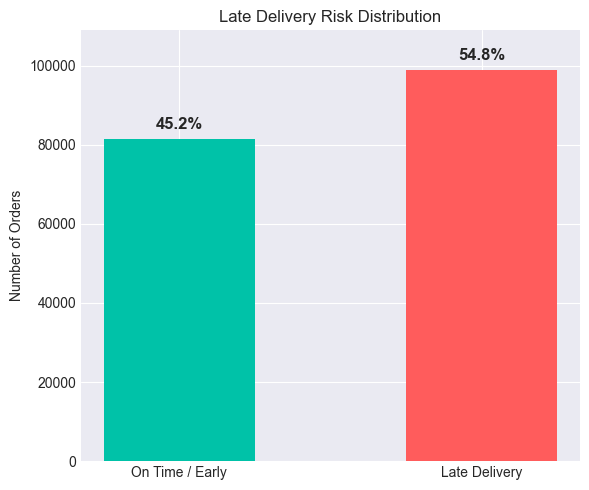

In [21]:
fig, ax = plt.subplots(figsize=(6, 5))

counts = df['Late_delivery_risk'].value_counts().sort_index()
labels = ['On Time / Early', 'Late Delivery']
bars = ax.bar(labels, counts, color=['#00C2A8', '#FF5C5C'], width=0.5)
total = len(df)
ax.bar_label(bars, 
             labels=[f'{val/total:.1%}' for val in counts], 
             padding=5, 
             fontsize=12, 
             fontweight='bold')

ax.set(title='Late Delivery Risk Distribution', ylabel='Number of Orders')
ax.spines[['top', 'right']].set_visible(False) #lines connecting the axis tick marks, defining the boundaries of a data area
ax.margins(y=0.1) # Prevents label cutoff

plt.tight_layout()
plt.show()

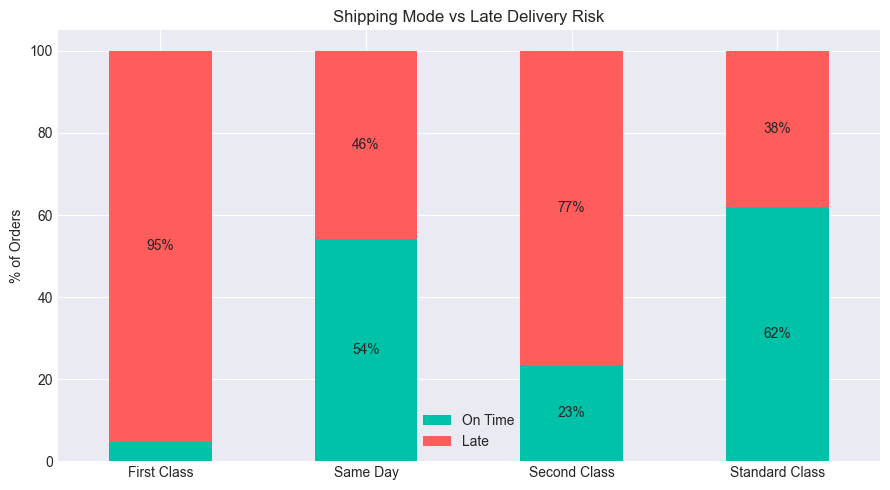

In [22]:
fig, ax = plt.subplots(figsize=(9, 5))

# Prepare data
mode_risk = df.groupby('Shipping Mode')['Late_delivery_risk'] \
              .value_counts(normalize=True).unstack() * 100
mode_risk.columns = ['On Time', 'Late']

# Plot
mode_risk.plot(kind='bar', stacked=True, ax=ax,
               color=['#00C2A8', '#FF5C5C'])

# Add labels for visible parts
for container in ax.containers:
    ax.bar_label(container,
                 labels=[f'{v:.0f}%' if v > 5 else '' for v in container.datavalues],
                 label_type='center')
    
ax.set(title='Shipping Mode vs Late Delivery Risk',
       xlabel='',
       ylabel='% of Orders')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

### Shipping Mode vs Late Delivery Risk

This chart shows the percentage of orders delivered **on time** versus **late** across different shipping modes.

### Key Insights

- **Standard Class** has the highest on-time delivery rate (62%).
- **Same Day** performs moderately well with a near 50/50 split.
- **Second Class** has a high late delivery rate (77%).
- **First Class** performs the worst, with **95% of orders delivered late**.

### Conclusion

Despite expectations, faster shipping methods like **First Class** show significantly higher late delivery risk, while **Standard Class** appears to be the most reliable option.

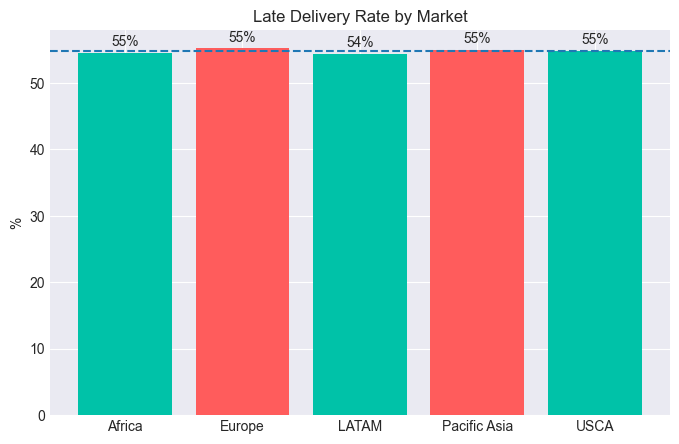

In [23]:
rates = df.groupby('Market')['Late_delivery_risk'].mean() * 100
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#FF5C5C' if v > 55 else '#00C2A8' for v in rates]
bars = ax.bar(rates.index, rates, color=colors)

# Labels 
ax.bar_label(bars, fmt='%.0f%%', padding=3)
ax.axhline(rates.mean(), ls='--', label=f'Avg: {rates.mean():.0f}%')
ax.set(title='Late Delivery Rate by Market', ylabel='%')
ax.spines[['top', 'right']].set_visible(False)

plt.show()

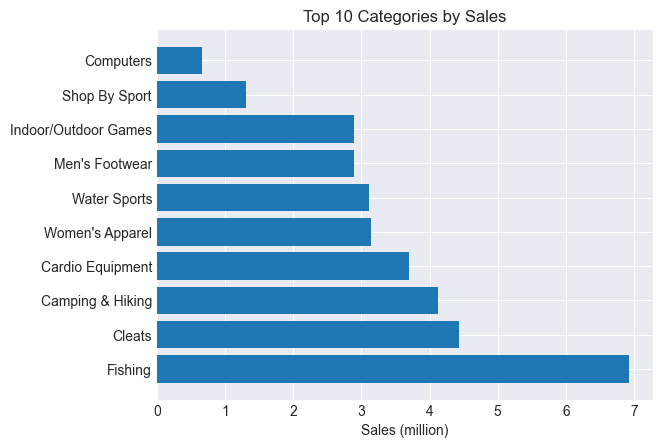

In [24]:
fig, ax = plt.subplots()
top_cats = df.groupby('Category Name')['Sales'].sum().nlargest(10)
# Convert large sales numbers into millions (e.g., 5,000,000 → 5)
sales_millions = top_cats / 1e6

# Plot categories vs sales horizontal bars
bars = ax.barh(top_cats.index, sales_millions)
ax.set(title='Top 10 Categories by Sales', xlabel='Sales (million)')
plt.show()

### Top 10 Categories by Sales

This chart highlights the top-performing product categories based on total sales (in millions).

### Sales by Category

1. **Fishing** — 6.9M±  
2. **Cleats** — 4.5M±  
3. **Camping & Hiking** — 4.1M±  
4. **Cardio Equipment** — 3.7M±  
5. **Women's Apparel** — 3.1M±  
6. **Water Sports** — 3.1M±  
7. **Men's Footwear** — 2.9M±  
8. **Indoor/Outdoor Games** — 2.9M±  
9. **Shop By Sport** — 1.3M±  
10. **Computers** — 0.6M±  

### Key Insights

- **Fishing** dominates all categories with a significant lead in sales.
- **Cleats** and **Camping & Hiking** are strong mid-tier performers.
- Categories like **Women's Apparel**, **Water Sports**, and **Cardio Equipment** show steady sales.
- **Computers** and **Shop By Sport** have the lowest sales among the top 10.

### Conclusion

Outdoor and sports-related categories (e.g., **Fishing**, **Camping & Hiking**, **Cleats**) drive the highest revenue, indicating strong customer interest in sports and outdoor gear.

### 8. Feature Engineering

In [ ]:
if 'order date (DateOrders)' in df.columns:
    df['order_date'] = pd.to_datetime(df['order date (DateOrders)'])
    df['order_month']     = df['order_date'].dt.month
    df['order_dayofweek'] = df['order_date'].dt.dayofweek
    df['order_quarter']   = df['order_date'].dt.quarter
    df.drop(columns=['order date (DateOrders)', 'order_date'], inplace=True)

df['profit_margin'] = df['Order Profit Per Order'] / df['Sales'].replace(0, np.nan)

print(f"Shape: {df.shape}")
print(df[['order_month', 'order_dayofweek', 'order_quarter', 'profit_margin']].head(3))


Shape: (180519, 29)
   order_month  order_dayofweek  order_quarter  profit_margin
0            1                2              1       0.278413
1            1                5              1      -0.760000
2            1                5              1      -0.756003


In [27]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
int_cols = df.select_dtypes(include='int').columns.tolist()

print("Categorical Columns:", cat_cols)
print("Numerical Columns:", int_cols)
print(f"Total categorical columns: {len(cat_cols)}")
print(f"Total integer columns: {len(int_cols)}")

Categorical Columns: ['Type', 'Category Name', 'Customer Segment', 'Department Name', 'Market', 'Order City', 'Order Country', 'Order Region', 'Order State', 'Product Name', 'Shipping Mode']
Numerical Columns: ['Days for shipment (scheduled)', 'Late_delivery_risk', 'Customer Id', 'Order Item Quantity', 'Product Card Id', 'Product Status', 'order_month', 'order_dayofweek', 'order_quarter']
Total categorical columns: 11
Total integer columns: 9


### 9. Feature Selection

In [28]:
# unique values for each categorical column
for col in cat_cols:
    print(f"{col}: {df[col].nunique()} unique values")

Type: 4 unique values
Category Name: 50 unique values
Customer Segment: 3 unique values
Department Name: 11 unique values
Market: 5 unique values
Order City: 3594 unique values
Order Country: 164 unique values
Order Region: 23 unique values
Order State: 1089 unique values
Product Name: 118 unique values
Shipping Mode: 4 unique values


#### 9.1 Geography Analysis

In [30]:
country_risk = df.groupby('Order Country')['Late_delivery_risk'].mean().sort_values()
print(country_risk.describe())
print("\n Countries with <50 orders:")
print(df['Order Country'].value_counts().tail(20))

count    164.000000
mean       0.556596
std        0.191560
min        0.000000
25%        0.508318
50%        0.554485
75%        0.602860
max        1.000000
Name: Late_delivery_risk, dtype: float64

 Countries with <50 orders:
Order Country
Guayana Francesa       9
Surinam                8
Oman                   8
Tayikistan             7
Eslovenia              6
Macedonia              6
Laos                   6
Suazilandia            5
Republica de Gambia    5
Sudan del Sur          5
Armenia                5
Butan                  5
Barein                 4
Chad                   3
Eritrea                2
Guinea Ecuatorial      2
Kuwait                 2
Sahara Occidental      2
Burundi                1
Serbia                 1
Name: count, dtype: int64


- most countries cluster tightly around 55% late delivery rate.
- 20+ countries have fewer than 50 orders - some have 1-2 orders. A model cannot learn anything reliable from 1 order, 100% late. It'll just memorize noise.

In [31]:
# Confirm: does Order Region already explain country-level variation?
region_risk = df.groupby('Order Region')['Late_delivery_risk'].mean().sort_values()
print(region_risk)
print(f"\nRegion std: {region_risk.std():.3f}")
print(f"Country std: {0.191:.3f}")

Order Region
Canada             0.488008
West Africa        0.528409
Caribbean          0.530777
Southern Africa    0.533276
West of USA        0.539597
Oceania            0.540205
Northern Europe    0.540441
South America      0.543087
Eastern Asia       0.543269
Southern Europe    0.543845
North Africa       0.545173
Central America    0.547546
US Center          0.552404
West Asia          0.552837
Central Asia       0.553345
Southeast Asia     0.555299
East of USA        0.556616
Eastern Europe     0.556633
South of  USA      0.557726
Western Europe     0.558486
East Africa        0.559395
South Asia         0.562670
Central Africa     0.579606
Name: Late_delivery_risk, dtype: float64

Region std: 0.017
Country std: 0.191


- Region std being tiny (0.017) means all 23 regions are bunched between 48% and 58%. Geography barely predicts late delivery at all 
- Country std being 0.191 is inflated by those tiny-sample countries

In [32]:
print(region_risk.max() - region_risk.min())

0.0915980980486158


- Range of only 0.09 across the entire world
- A 9 percentage point spread across all world regions tells you that where the order is going barely matters. The model will learn almost nothing useful from geography.

In [33]:
geo_cols = ['Market', 'Order Region', 'Order Country', 
            'Latitude', 'Longitude']
df.drop(columns=geo_cols, inplace=True)
print(df.shape)

(180519, 24)


#### 9.2 Remaining Checks

In [ ]:
# Quick check on everything suspicious
suspicious = ['Customer Id', 'Product Card Id', 'Order City', 
              'Order State', 'profit_margin', 'Product Status']

for col in suspicious:
    rate = df.groupby(col)['Late_delivery_risk'].mean()
    print(f"\n{col} | unique={df[col].nunique()} | std={rate.std():.3f}")


Customer Id | unique=20652 | std=0.384

Product Card Id | unique=118 | std=0.047

Order City | unique=3594 | std=0.280

Order State | unique=1089 | std=0.226

profit_margin | unique=57102 | std=0.417

Product Status | unique=1 | std=nan


In [35]:
print(df['Product Status'].value_counts())
print(df.groupby('Product Status')['Late_delivery_risk'].mean())

Product Status
0    180519
Name: count, dtype: int64
Product Status
0    0.548291
Name: Late_delivery_risk, dtype: float64


In [36]:
# Order Item Profit Ratio — is this calculated post-delivery or at order time?
print(df['Order Item Profit Ratio'].describe())
# If it correlates perfectly with Order Profit Per Order → redundant
print(df[['Order Item Profit Ratio', 'Order Profit Per Order', 'Sales']].corr())

count    180519.000000
mean          0.120647
std           0.466796
min          -2.750000
25%           0.080000
50%           0.270000
75%           0.360000
max           0.500000
Name: Order Item Profit Ratio, dtype: float64
                         Order Item Profit Ratio  Order Profit Per Order  \
Order Item Profit Ratio                 1.000000                0.823689   
Order Profit Per Order                  0.823689                1.000000   
Sales                                  -0.001766                0.131816   

                            Sales  
Order Item Profit Ratio -0.001766  
Order Profit Per Order   0.131816  
Sales                    1.000000  


**Decisions:**
- `Customer Id`, `Product Card Id` - random IDs, nothing predictive → drop
- `Order City` (3,594 unique), `Order State` (1,089 unique) - same noise problem as country → drop
- `profit_margin` - redundant with Sales + Profit columns, has infinite risk → drop
- `Product Status` - zero variance (all 0s) → drop
- `Order Item Profit Ratio` - correlation with Profit=0.82, Sales=-0.001 → **keeping** (not redundant)

In [37]:
cols_to_drop = [
    'Customer Id',
    'Product Card Id',
    'Order City',
    'Order State',
    'profit_margin',
    'Product Status',   # zero variance
]

df.drop(columns=cols_to_drop, inplace=True)
print("Final shape:", df.shape)
print(df.columns.tolist())

Final shape: (180519, 18)
['Type', 'Days for shipment (scheduled)', 'Late_delivery_risk', 'Category Name', 'Customer Segment', 'Department Name', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Profit Per Order', 'Product Name', 'Shipping Mode', 'order_month', 'order_dayofweek', 'order_quarter']


### 10. Preprocessing

#### 10.1 Train / Test Split

In [38]:
X = df.drop(columns=['Late_delivery_risk'])
y = df['Late_delivery_risk']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape)
print("Test: ", X_test.shape)
print("\nTarget distribution in train:")
print(y_train.value_counts(normalize=True).round(3))
print("\nTarget distribution in test:")
print(y_test.value_counts(normalize=True).round(3))

Train: (144415, 17)
Test:  (36104, 17)

Target distribution in train:
Late_delivery_risk
1    0.548
0    0.452
Name: proportion, dtype: float64

Target distribution in test:
Late_delivery_risk
1    0.548
0    0.452
Name: proportion, dtype: float64


In [39]:
print(X_train.columns.tolist())

['Type', 'Days for shipment (scheduled)', 'Category Name', 'Customer Segment', 'Department Name', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Profit Per Order', 'Product Name', 'Shipping Mode', 'order_month', 'order_dayofweek', 'order_quarter']


In [40]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(cat_cols)

for col in cat_cols:
    print(f"{col}: {df[col].nunique()} unique values")

['Type', 'Category Name', 'Customer Segment', 'Department Name', 'Product Name', 'Shipping Mode']
Type: 4 unique values
Category Name: 50 unique values
Customer Segment: 3 unique values
Department Name: 11 unique values
Product Name: 118 unique values
Shipping Mode: 4 unique values


#### 10.2 Encoding Strategy

In [41]:
# One-Hot: low cardinality (≤11 unique)
ohe_cols = ['Type', 'Customer Segment', 'Shipping Mode', 'Department Name']

# Target/Ordinal: medium-high cardinality
ord_cols = ['Category Name', 'Product Name']

# Numeric: no encoding 
num_cols = [c for c in X_train.columns if c not in ohe_cols + ord_cols]

print("OneHotEncoding cols:", ohe_cols)
print("Ordinal cols:", ord_cols)
print("Numeric cols:", num_cols)

OneHotEncoding cols: ['Type', 'Customer Segment', 'Shipping Mode', 'Department Name']
Ordinal cols: ['Category Name', 'Product Name']
Numeric cols: ['Days for shipment (scheduled)', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Profit Per Order', 'order_month', 'order_dayofweek', 'order_quarter']


In [42]:
# One-Hot Encode
X_train_ohe = pd.get_dummies(X_train[ohe_cols], drop_first=False)
X_test_ohe  = pd.get_dummies(X_test[ohe_cols],  drop_first=False)
X_train_ohe, X_test_ohe = X_train_ohe.align(X_test_ohe, join='left', axis=1, fill_value=0)

# Ordinal Encode (train only)
oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X_train_ord = pd.DataFrame(
    oe.fit_transform(X_train[ord_cols]),
    columns=ord_cols,
    index=X_train.index
)
X_test_ord = pd.DataFrame(
    oe.transform(X_test[ord_cols]), 
    columns=ord_cols,
    index=X_test.index
)

# Combine → this is base encoded set
X_train_encoded = pd.concat([X_train[num_cols], X_train_ohe, X_train_ord], axis=1)
X_test_encoded  = pd.concat([X_test[num_cols],  X_test_ohe,  X_test_ord],  axis=1)

print("Encoded shape:", X_train_encoded.shape)

Encoded shape: (144415, 35)


#### 10.3 Scaling

Tree models (RF, XGBoost, GB) don't need scaling - they split on thresholds.
Distance/gradient models (LR, KNN) do - large values dominate otherwise.

- `X_train_trees / X_test_trees` → unscaled, for tree models
- `X_train_scaled / X_test_scaled` → StandardScaler, for LR and KNN

Scaler fit on train only → no leakage.

In [43]:
# Version 1: unscaled → for tree models
X_train_trees = X_train_encoded.copy()
X_test_trees  = X_test_encoded.copy()

# Version 2: scaled → for LR and KNN
# Fit scaler on train only, transform both
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_encoded),
    columns=X_train_encoded.columns,
    index=X_train_encoded.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test_encoded),
    columns=X_test_encoded.columns,
    index=X_test_encoded.index
)

print("Trees shape: ", X_train_trees.shape)
print("Scaled shape:", X_train_scaled.shape)

Trees shape:  (144415, 35)
Scaled shape: (144415, 35)


#### warning with the Logistic Regression -> so changed approch created two different version scaled and unscaled
- ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
- STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT
- Increase the number of iterations to improve the convergence (max_iter=1000).

### 11. Model Comparison

In [ ]:
# Each model paired with the correct data version

models = {
    'Logistic Regression': (LogisticRegression(max_iter=5000, random_state=42),
                            X_train_scaled, X_test_scaled),
    'KNN':                 (KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
                            X_train_scaled, X_test_scaled),
    'Random Forest':       (RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
                            X_train_trees, X_test_trees),
    'Gradient Boosting':   (GradientBoostingClassifier(n_estimators=100, random_state=42),
                            X_train_trees, X_test_trees),
    'XGBoost':             (XGBClassifier(n_estimators=100, random_state=42,
                                          eval_metric='auc', n_jobs=-1, verbosity=0),
                            X_train_trees, X_test_trees),
}

results = []
trained_models = {}

for name, (model, X_tr, X_te) in models.items():
    start = time.time()
    model.fit(X_tr, y_train)
    elapsed = time.time() - start

    trained_models[name] = (model, X_tr, X_te)  # store fit models

    y_pred  = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]
    report  = classification_report(y_test, y_pred,
                                     target_names=['On Time', 'Late'],
                                     output_dict=True)
    results.append({
        'Model':          name,
        'AUC':            round(roc_auc_score(y_test, y_proba), 4),
        'Accuracy':       round(report['accuracy'], 4),
        'Precision_Late': round(report['Late']['precision'], 4),
        'Recall_Late':    round(report['Late']['recall'], 4),
        'F1_Late':        round(report['Late']['f1-score'], 4),
        'Train Time(s)':  round(elapsed, 2)
    })

results_df = pd.DataFrame(results).sort_values('AUC', ascending=False)
print(results_df.to_string(index=False))

              Model    AUC  Accuracy  Precision_Late  Recall_Late  F1_Late  Train Time(s)
  Gradient Boosting 0.7431    0.6965          0.8459       0.5460   0.6636          25.21
Logistic Regression 0.7421    0.6966          0.8457       0.5463   0.6638           0.23
            XGBoost 0.7390    0.6926          0.8099       0.5740   0.6719           0.52
      Random Forest 0.7316    0.6710          0.7308       0.6331   0.6784           7.04
                KNN 0.7078    0.6512          0.6908       0.6586   0.6743           0.03


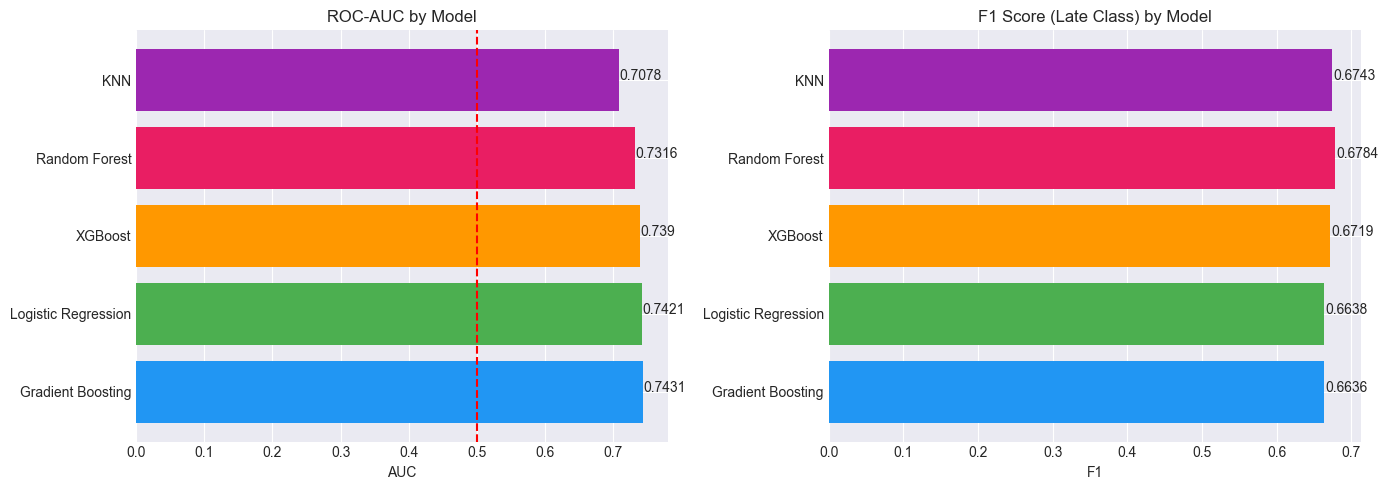

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63', '#9C27B0']

# --- AUC Plot ---
axes[0].barh(results_df['Model'], results_df['AUC'], color=colors)
axes[0].set_title('ROC-AUC by Model')
axes[0].set_xlabel('AUC')
axes[0].axvline(0.5, linestyle='--', color='red') 

for i, value in enumerate(results_df['AUC']):
    axes[0].text(value + 0.001, i, str(value))

# --- F1 Plot ---
axes[1].barh(results_df['Model'], results_df['F1_Late'], color=colors)
axes[1].set_title('F1 Score (Late Class) by Model')
axes[1].set_xlabel('F1')

for i, value in enumerate(results_df['F1_Late']):
    axes[1].text(value + 0.001, i, str(value))

plt.tight_layout()
plt.show()

#### 11.1 Overfit Check

In [46]:
for name in ['Gradient Boosting', 'Logistic Regression', 'XGBoost', 'Random Forest']:
    model, X_tr, X_te = trained_models[name]
    train_auc = roc_auc_score(y_train, model.predict_proba(X_tr)[:, 1])
    test_auc  = roc_auc_score(y_test,  model.predict_proba(X_te)[:, 1])
    gap       = train_auc - test_auc

    if gap < 0.02:
        status = 'Excellent'
    elif gap < 0.05:
        status = 'Normal'
    elif gap < 0.10:
        status = 'Mild overfit'
    elif gap < 0.20:
        status = 'Moderate overfit'
    else:
        status = 'Severe overfit'

    print(f"{name}")
    print(f"Train AUC:{train_auc:.4f}")
    print(f"Test AUC:{test_auc:.4f}")
    print(f"Gap: {gap:.4f}  {status}")
    print()

Gradient Boosting
Train AUC:0.7490
Test AUC:0.7431
Gap: 0.0059  Excellent

Logistic Regression
Train AUC:0.7417
Test AUC:0.7421
Gap: -0.0004  Excellent

XGBoost
Train AUC:0.8052
Test AUC:0.7390
Gap: 0.0662  Mild overfit

Random Forest
Train AUC:1.0000
Test AUC:0.7316
Gap: 0.2684  Severe overfit



#### 11.2 Full Metric Comparison

In [47]:
for name in ['Gradient Boosting', 'Logistic Regression', 'XGBoost', 'Random Forest']:
    model, X_tr, X_te = trained_models[name]
    
    y_pred  = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]
    report  = classification_report(y_test, y_pred, target_names=['On Time', 'Late'], output_dict=True)
    
    train_auc = roc_auc_score(y_train, model.predict_proba(X_tr)[:, 1])
    test_auc  = roc_auc_score(y_test,  y_proba)
    gap       = train_auc - test_auc

    print(f"{'─'*50}")
    print(f"Model: {name}")
    print(f" AUC: {test_auc:.4f} (train gap: {gap:.4f})")
    print(f"Accuracy: {report['accuracy']:.4f}")
    print("─── Late Delivery ───")
    print(f"Precision: {report['Late']['precision']:.4f}  (of predicted late, how many truly late)")
    print(f"Recall:{report['Late']['recall']:.4f}  (of actual late, how many caught)")
    print(f"F1: {report['Late']['f1-score']:.4f}  (balance of precision & recall)")
    print("─── On Time ────")
    print(f"Precision: {report['On Time']['precision']:.4f}")
    print(f"Recall: {report['On Time']['recall']:.4f}")
    print(f"F1: {report['On Time']['f1-score']:.4f}")
    print("─── Cost ────")
    
    tn = report['On Time']['recall'] * (y_test == 0).sum()
    fp = (1 - report['On Time']['recall']) * (y_test == 0).sum()
    fn = (1 - report['Late']['recall']) * (y_test == 1).sum()
    tp = report['Late']['recall'] * (y_test == 1).sum()
    
    print(f"Missed late deliveries (FN): {int(fn):,} most costly")
    print(f" False alarms (FP): {int(fp):,} operational cost")
    print()

──────────────────────────────────────────────────
Model: Gradient Boosting
 AUC: 0.7431 (train gap: 0.0059)
Accuracy: 0.6965
─── Late Delivery ───
Precision: 0.8459  (of predicted late, how many truly late)
Recall:0.5460  (of actual late, how many caught)
F1: 0.6636  (balance of precision & recall)
─── On Time ────
Precision: 0.6147
Recall: 0.8793
F1: 0.7236
─── Cost ────
Missed late deliveries (FN): 8,988 most costly
 False alarms (FP): 1,969 operational cost

──────────────────────────────────────────────────
Model: Logistic Regression
 AUC: 0.7421 (train gap: -0.0004)
Accuracy: 0.6966
─── Late Delivery ───
Precision: 0.8457  (of predicted late, how many truly late)
Recall:0.5463  (of actual late, how many caught)
F1: 0.6638  (balance of precision & recall)
─── On Time ────
Precision: 0.6148
Recall: 0.8790
F1: 0.7236
─── Cost ────
Missed late deliveries (FN): 8,981 most costly
 False alarms (FP): 1,972 operational cost

──────────────────────────────────────────────────
Model: XGBoo

### Model Selection: XGBoost

| Model | AUC | Recall | FN | Gap |
|---|---|---|---|---|
| Gradient Boosting | 0.7431 | 0.546 | 8,988 | 0.006  |
| Logistic Regression | 0.7421 | 0.547 | 8,981 | 0.000  |
| **XGBoost** | **0.7390** | **0.574** | **8,433** | **0.066** |
| Random Forest | 0.7316 | 0.633 | 7,264 | 0.268  |

**XGBoost chosen** — best F1, best recall among non-overfitted models, fast tuning. Overfit gap fixable via regularization.

### 12. Hyperparameter Tuning

In [48]:
param_grid = {
    'n_estimators':     [100, 200, 300, 500],
    'max_depth':        [3, 4, 5, 6],        # lower = less overfit
    'learning_rate':    [0.01, 0.05, 0.1, 0.2],
    'subsample':        [0.7, 0.8, 0.9],     # row sampling = less overfit
    'colsample_bytree': [0.7, 0.8, 0.9],     # feature sampling = less overfit
    'min_child_weight': [1, 3, 5, 7],        # higher = less overfit
    'gamma':            [0, 0.1, 0.2, 0.5],  # min split gain = less overfit
    'reg_alpha':        [0, 0.1, 0.5, 1.0],  # L1 regularization
    'reg_lambda':       [1.0, 1.5, 2.0],     # L2 regularization
}

xgb_base = XGBClassifier( random_state=42, eval_metric='auc', n_jobs=-1, verbosity=0
)

search = RandomizedSearchCV(
    xgb_base,
    param_distributions=param_grid,
    n_iter=50,
    scoring='f1',          # optimize for F1 since recall matters most
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train_trees, y_train)

print(f"Best CV F1:  {search.best_score_:.4f}")
print(f"Best params: {search.best_params_}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best CV F1:  0.6765
Best params: {'subsample': 0.9, 'reg_lambda': 2.0, 'reg_alpha': 1.0, 'n_estimators': 500, 'min_child_weight': 7, 'max_depth': 6, 'learning_rate': 0.2, 'gamma': 0.1, 'colsample_bytree': 0.7}


### 13. Final Model

#### 13.1 Train with Early Stopping

RandomizedSearchCV found `learning_rate=0.2, n_estimators=500` but verbose output showed test AUC declining after tree 0 - the model was overfitting. Fix: lower learning rate + early stopping to find optimal n_estimators automatically.

In [ ]:
xgb_tuned = XGBClassifier(
    subsample=0.9,
    reg_lambda=2.0,
    reg_alpha=1.0,
    min_child_weight=7,
    max_depth=4,         
    learning_rate=0.05, 
    gamma=0.1,
    colsample_bytree=0.7,
    n_estimators=1000,    # high ceiling, early stopping will cut it
    early_stopping_rounds=30,
    random_state=42,
    eval_metric='auc',
    n_jobs=-1,
    verbosity=0
)

xgb_tuned.fit(
    X_train_trees, y_train,
    eval_set=[(X_train_trees, y_train), (X_test_trees, y_test)],
    verbose=50,
)

print(f"\nBest iteration: {xgb_tuned.best_iteration}")
print(f"Best test AUC:  {xgb_tuned.best_score:.4f}")

# Full evaluation
y_pred_tuned  = xgb_tuned.predict(X_test_trees)
y_proba_tuned = xgb_tuned.predict_proba(X_test_trees)[:, 1]

[0]	validation_0-auc:0.74222	validation_1-auc:0.74181
[50]	validation_0-auc:0.74707	validation_1-auc:0.74478
[87]	validation_0-auc:0.74894	validation_1-auc:0.74454

Best iteration: 57
Best test AUC:  0.7452


── Final Model: Tuned XGBoost threshold ── 
              precision    recall  f1-score   support

     On Time       0.63      0.68      0.65     16308
        Late       0.72      0.67      0.69     19796

    accuracy                           0.67     36104
   macro avg       0.67      0.67      0.67     36104
weighted avg       0.68      0.67      0.67     36104

AUC: 0.7452
Missed Late (FN): 6,513
False Alarms (FP): 5,272


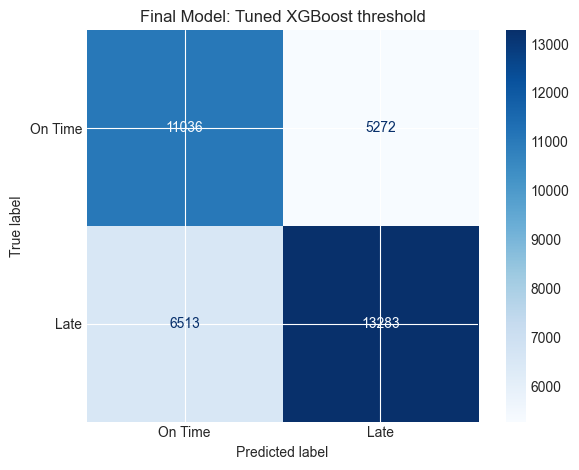

In [79]:
y_pred_final = (y_proba_tuned >= 0.41).astype(int)

print("── Final Model: Tuned XGBoost threshold ── ")
print(classification_report(y_test, y_pred_final,
                              target_names=['On Time', 'Late'],
                              zero_division=0))
print(f"AUC: {roc_auc_score(y_test, y_proba_tuned):.4f}")

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_final).ravel()
print(f"Missed Late (FN): {fn:,}")
print(f"False Alarms (FP): {fp:,}")

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_final,
    display_labels=['On Time', 'Late'],
    cmap='Blues'
)
plt.title('Final Model: Tuned XGBoost threshold')
plt.tight_layout()
plt.show()

### 14. Feature Importance

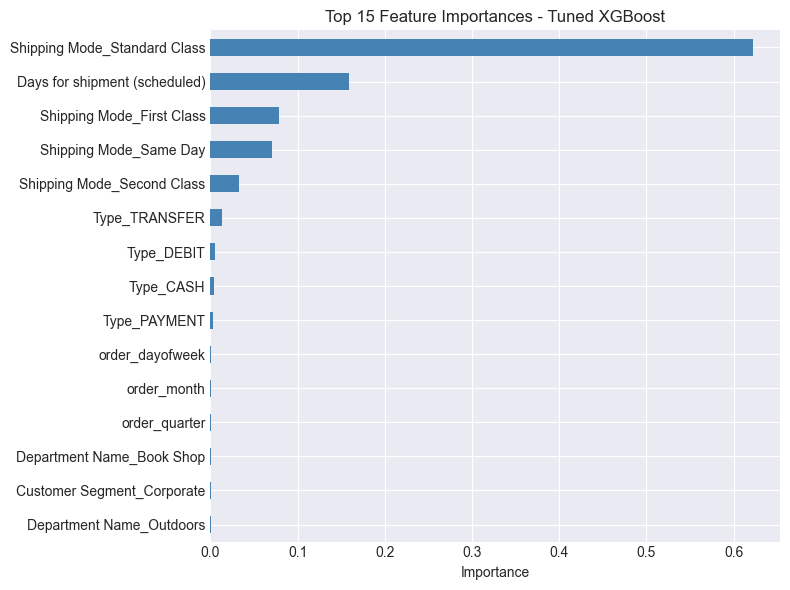

In [65]:
importances = pd.Series(
    xgb_tuned.feature_importances_,
    index=X_train_trees.columns
).nlargest(15).sort_values()

fig, ax = plt.subplots(figsize=(8, 6))
importances.plot(kind='barh', ax=ax, color='steelblue')
ax.set(title='Top 15 Feature Importances - Tuned XGBoost',
       xlabel='Importance')
plt.tight_layout()
plt.show()

#### Feature Importance Insights

- **Shipping Mode dominates** — 79% combined importance (Standard Class = 62%)
- **Days for shipment (scheduled)** — only other meaningful predictor (16%)
- All other features contribute <2% each

This confirms the EDA finding: Shipping Mode is the primary driver of late delivery risk.

| Shipping Mode | Late Rate | Model Importance |
|---|---|---|
| Standard Class | 38% | 62% |
| First Class | 95% | 8% |
| Same Day | 46% | 7% |
| Second Class | 77% | 2% |

### Business Implication
To reduce late deliveries, focus on **how orders are shipped**, not where they go or what product is ordered.

### 15. Pipeline 

In [112]:
preprocessor = ColumnTransformer(transformers=[
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False), ohe_cols),
    ('ord', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), ord_cols),
], remainder='passthrough')

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(
        subsample=0.9, reg_lambda=2.0, reg_alpha=1.0,
        min_child_weight=7, max_depth=4, learning_rate=0.05,
        gamma=0.1, colsample_bytree=0.7,
        n_estimators=57,      # best iteration from early stopping run
        random_state=42, eval_metric='auc', n_jobs=-1, verbosity=0
    ))
])

pipeline.fit(X_train, y_train)

print("Pipeline trained.")

y_proba_p = pipeline.predict_proba(X_test)[:, 1]

os.makedirs('models', exist_ok=True)
joblib.dump(pipeline, 'models/pipeline.pkl')
print("Saved: models/pipeline.pkl")

Pipeline trained.
Saved: models/pipeline.pkl


In [113]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(pipeline, X, y, cv=cv, scoring='roc_auc')
print(f"CV AUC: {scores.mean():.4f} ± {scores.std():.4f}")

CV AUC: 0.7426 ± 0.0032
